In [39]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Robert\Desktop\projeto_01\data\stg\stg_moedas_silver.csv")

In [41]:
# Converte a coluna 'data' de texto para o formato Datetime do Pandas
df["data"] = pd.to_datetime(df["data"])

In [42]:
linha_da_maior_variaçao = df[df["pctChange"] == df["pctChange"].max()]
linha_da_maior_variaçao

,code,codein,name,high,low,varBid,pctChange,bid,ask,moeda,data
1550,BTC,BRL,Bitcoin/Real Brasileiro,375946.0,317250.0,37556.0,11.296,369869.0,370116.0,BTC-BRL,2026-02-07


In [43]:
linha_da_menor_variaçao = df[df["pctChange"] == df["pctChange"].min()]
linha_da_menor_variaçao

,code,codein,name,high,low,varBid,pctChange,bid,ask,moeda,data
1551,BTC,BRL,Bitcoin/Real Brasileiro,384138.0,328600.0,-51479.0,-13.428,331905.0,332025.0,BTC-BRL,2026-02-06


In [44]:
extremos_btc = pd.concat([linha_da_maior_variaçao, linha_da_menor_variaçao])
extremos_btc

,code,codein,name,high,low,varBid,pctChange,bid,ask,moeda,data
1550,BTC,BRL,Bitcoin/Real Brasileiro,375946.0,317250.0,37556.0,11.296,369869.0,370116.0,BTC-BRL,2026-02-07
1551,BTC,BRL,Bitcoin/Real Brasileiro,384138.0,328600.0,-51479.0,-13.428,331905.0,332025.0,BTC-BRL,2026-02-06


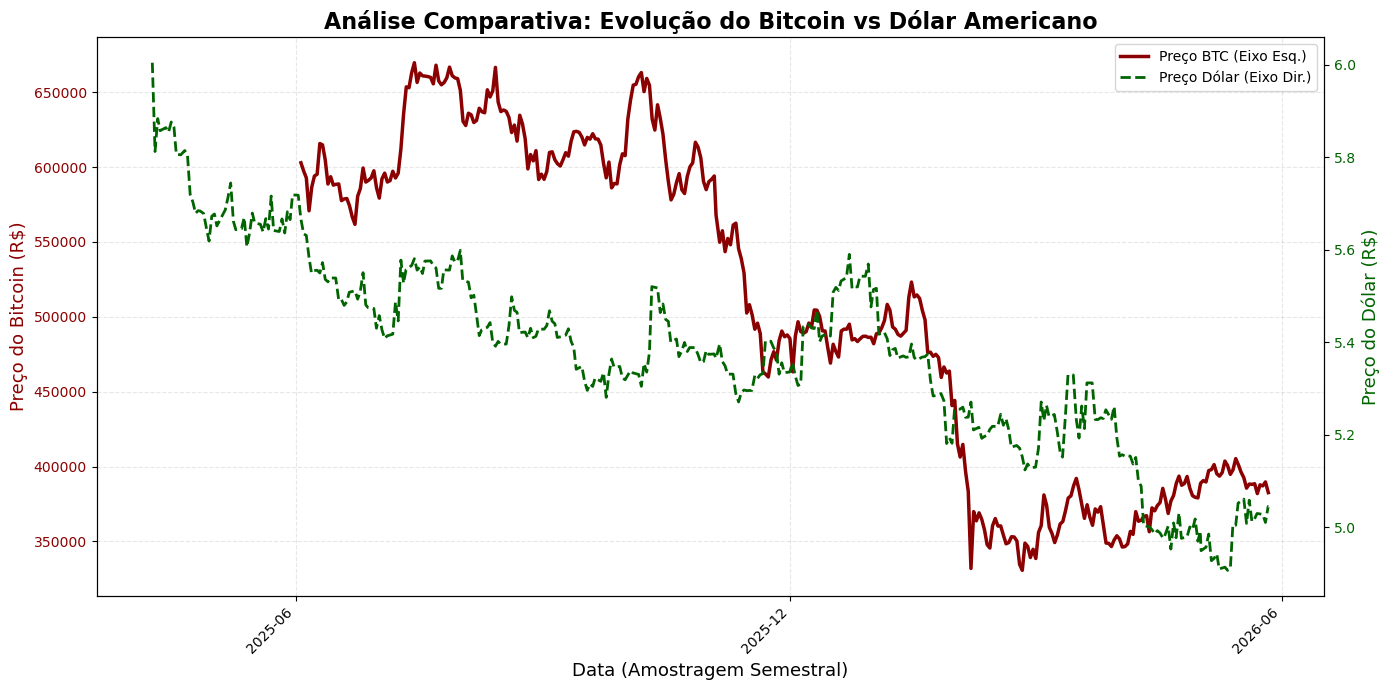

--------------------------------------------------
Veredito Estatístico: O Índice de Correlação de Pearson é 0.79
--------------------------------------------------


In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ==========================================
# PASSO 1: PREPARAÇÃO E FILTRAGEM DOS DADOS
# ==========================================
df["data"] = pd.to_datetime(df["data"])

df_btc = df[df["moeda"] == "BTC-BRL"].sort_values(by="data")
df_usd = df[df["moeda"] == "USD-BRL"].sort_values(by="data")

# ==========================================
# PASSO 2: O CÁLCULO DA CORRELAÇÃO DE PEARSON
# ==========================================
# Alinhamos as duas moedas pela data para o cálculo ser perfeito
serie_btc = df_btc.set_index("data")["bid"]
serie_usd = df_usd.set_index("data")["bid"]

# A função .corr() faz toda aquela matemática da fórmula por trás dos panos
indice_pearson = serie_btc.corr(serie_usd, method="pearson")

# ==========================================
# PASSO 3: CONSTRUÇÃO DO GRÁFICO DUPLO
# ==========================================
fig, ax1 = plt.subplots(figsize=(14, 7))

# Desenha o Bitcoin (Eixo Esquerdo)
color_btc = "darkred"
ax1.plot(df_btc["data"], df_btc["bid"], color=color_btc, linewidth=2.5, label="Preço BTC (Eixo Esq.)")
ax1.set_xlabel("Data (Amostragem Semestral)", fontsize=13)
ax1.set_ylabel("Preço do Bitcoin (R$)", color=color_btc, fontsize=13)
ax1.tick_params(axis='y', labelcolor=color_btc)

# Cria o eixo gêmeo para o Dólar (Eixo Direito)
ax2 = ax1.twinx()
color_usd = "darkgreen"
ax2.plot(df_usd["data"], df_usd["bid"], color=color_usd, linewidth=2, linestyle="--", label="Preço Dólar (Eixo Dir.)")
ax2.set_ylabel("Preço do Dólar (R$)", color=color_usd, fontsize=13)
ax2.tick_params(axis='y', labelcolor=color_usd)

# Ajuste das datas no eixo X
fmt_half_year = mdates.MonthLocator(interval=6)
ax1.xaxis.set_major_locator(fmt_half_year)
fmt_date = mdates.DateFormatter("%Y-%m")
ax1.xaxis.set_major_formatter(fmt_date)
fig.autofmt_xdate(rotation=45)

# Unificar as legendas
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.title("Análise Comparativa: Evolução do Bitcoin vs Dólar Americano", fontsize=16, fontweight='bold')
ax1.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()

# ==========================================
# PASSO 4: SALVAR O GRÁFICO NO COMPUTADOR
# ==========================================
# Salva a imagem na mesma pasta do seu arquivo do Jupyter
plt.savefig("analise_btc_vs_usd.png", dpi=300, bbox_inches="tight")

# Mostra o gráfico na tela do Jupyter
plt.show()

# ==========================================
# PASSO 5: EXIBIR O VEREDITO MATEMÁTICO
# ==========================================
print("-" * 50)
print(f"Veredito Estatístico: O Índice de Correlação de Pearson é {indice_pearson:.2f}")
print("-" * 50)